In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["figure.dpi"] = 120

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [5]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

print("Dataset Shape:", df.shape)

display(df.head())

display(df.sample(5))

display(df.info())

Dataset Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.10,308.60,1551,42.80,0,0,0,0,0,0,0
1,2,L47181,L,298.20,308.70,1408,46.30,3,0,0,0,0,0,0
2,3,L47182,L,298.10,308.50,1498,49.40,5,0,0,0,0,0,0
3,4,L47183,L,298.20,308.60,1433,39.50,7,0,0,0,0,0,0
4,5,L47184,L,298.20,308.70,1408,40.00,9,0,0,0,0,0,0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
3423,3424,L50603,L,301.40,310.40,1496,35.20,153,0,0,0,0,0,0
9054,9055,M23914,M,297.30,308.40,1521,38.20,87,0,0,0,0,0,0
5780,5781,L52960,L,301.70,311.20,1517,42.40,113,0,0,0,0,0,0
5076,5077,L52256,L,304.20,313.20,1464,44.90,37,0,0,0,0,0,0
1957,1958,H31371,H,297.90,307.70,1618,35.90,92,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

None

In [6]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean()*100).round(2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
UDI,0,0.00
Product ID,0,0.00
Type,0,0.00
Air temperature [K],0,0.00
Process temperature [K],0,0.00
Rotational speed [rpm],0,0.00
Torque [Nm],0,0.00
Tool wear [min],0,0.00
Machine failure,0,0.00
TWF,0,0.00


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [10]:
summary = df.describe().T

summary["median"] = df.median(numeric_only=True)
summary["skewness"] = df.skew(numeric_only=True)

summary

,count,mean,std,min,25%,50%,75%,max,median,skewness
UDI,10000.00,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00,5000.50,0.00
Air temperature [K],10000.00,300.00,2.00,295.30,298.30,300.10,301.50,304.50,300.10,0.11
Process temperature [K],10000.00,310.01,1.48,305.70,308.80,310.10,311.10,313.80,310.10,0.02
Rotational speed [rpm],10000.00,1538.78,179.28,1168.00,1423.00,1503.00,1612.00,2886.00,1503.00,1.99
Torque [Nm],10000.00,39.99,9.97,3.80,33.20,40.10,46.80,76.60,40.10,-0.01
Tool wear [min],10000.00,107.95,63.65,0.00,53.00,108.00,162.00,253.00,108.00,0.03
Machine failure,10000.00,0.03,0.18,0.00,0.00,0.00,0.00,1.00,0.00,5.15
TWF,10000.00,0.00,0.07,0.00,0.00,0.00,0.00,1.00,0.00,14.64
HDF,10000.00,0.01,0.11,0.00,0.00,0.00,0.00,1.00,0.00,9.16
PWF,10000.00,0.01,0.10,0.00,0.00,0.00,0.00,1.00,0.00,10.11


In [11]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print(num_cols)
print(cat_cols)

Index(['UDI', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')
Index(['Product ID', 'Type'], dtype='object')


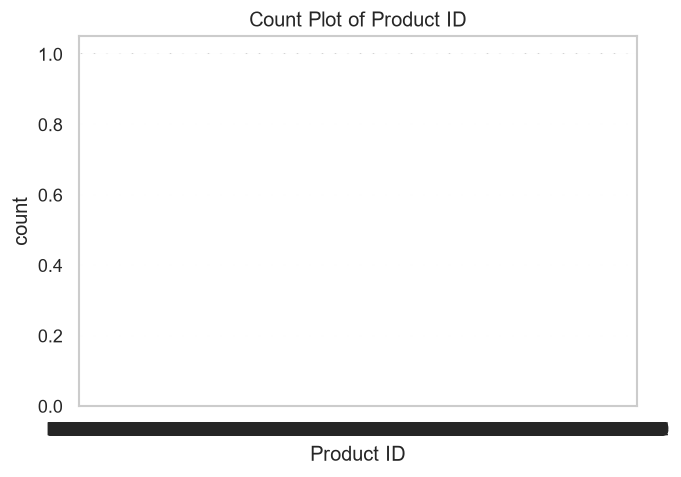

Product ID
M14860   0.01
L53850   0.01
L53843   0.01
L53844   0.01
L53845   0.01
         ... 
M18193   0.01
M18194   0.01
L50515   0.01
L50516   0.01
M24859   0.01
Name: proportion, Length: 10000, dtype: float64

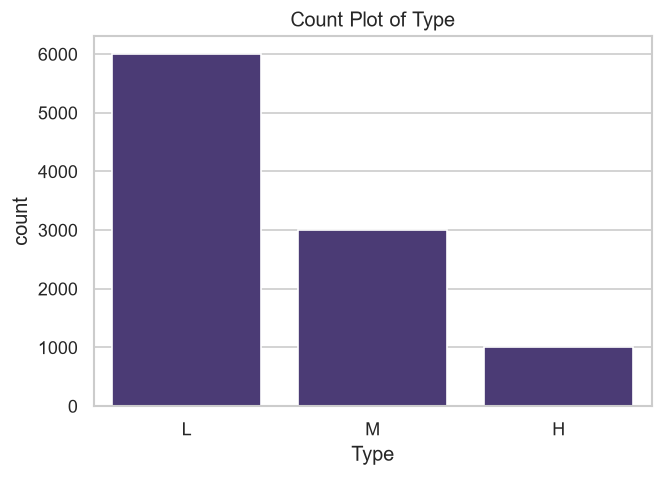

Type
L   60.00
M   29.97
H   10.03
Name: proportion, dtype: float64

In [12]:
for col in cat_cols:
    plt.figure(figsize=(6,4))

    sns.countplot(data=df, x=col, order=df[col].value_counts().index)

    plt.title(f"Count Plot of {col}")
    plt.show()

    display(df[col].value_counts(normalize=True)*100)

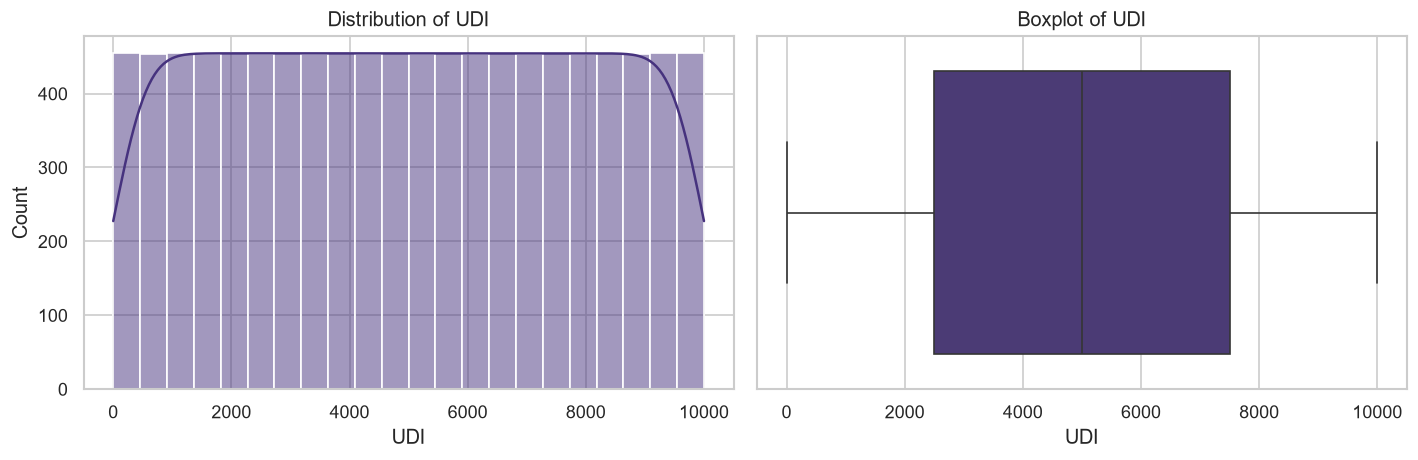

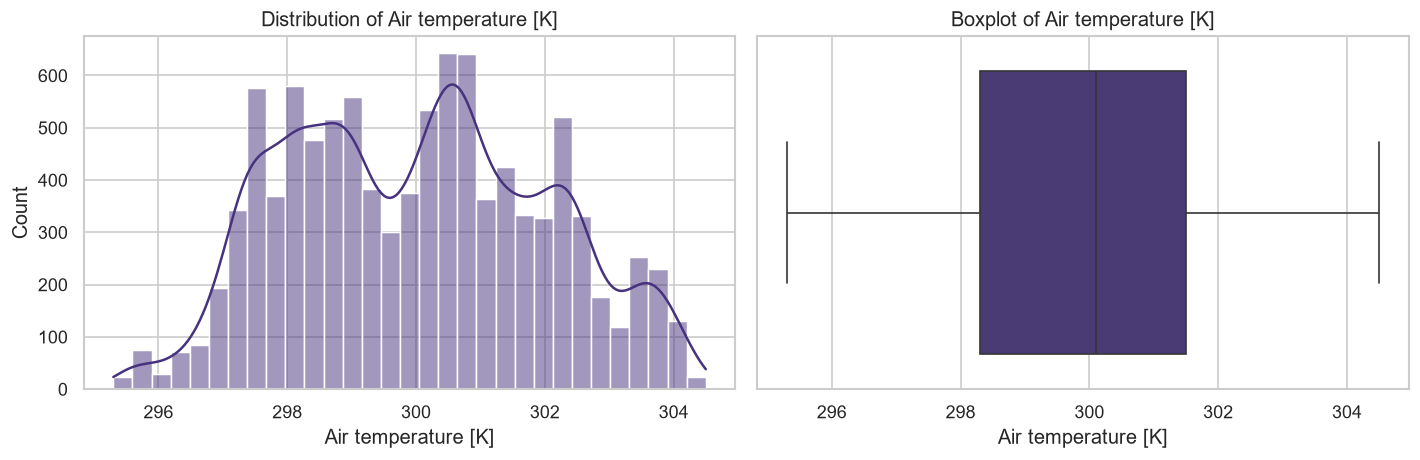

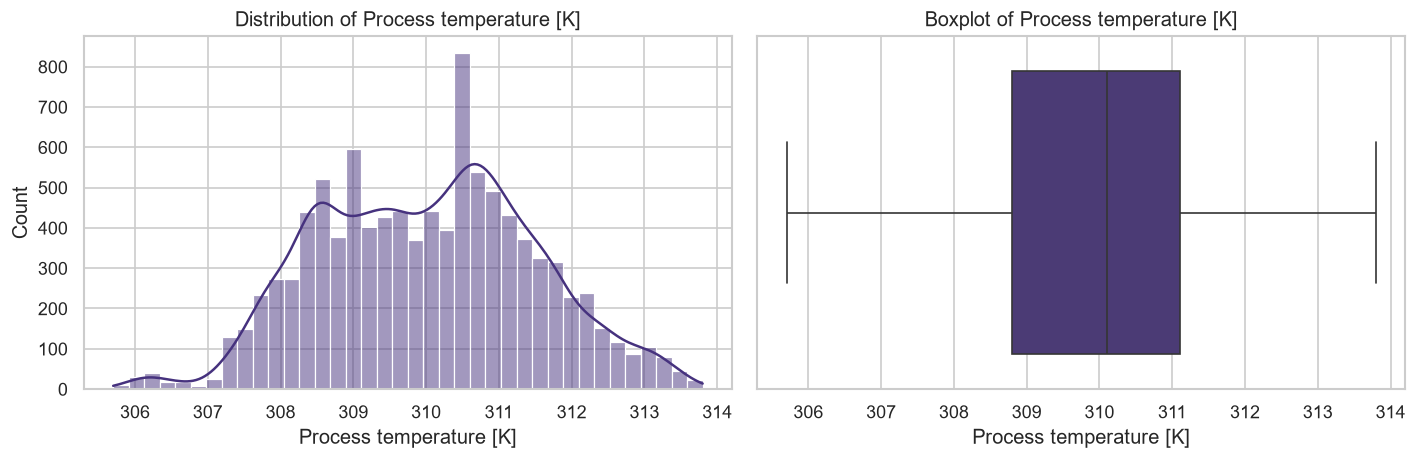

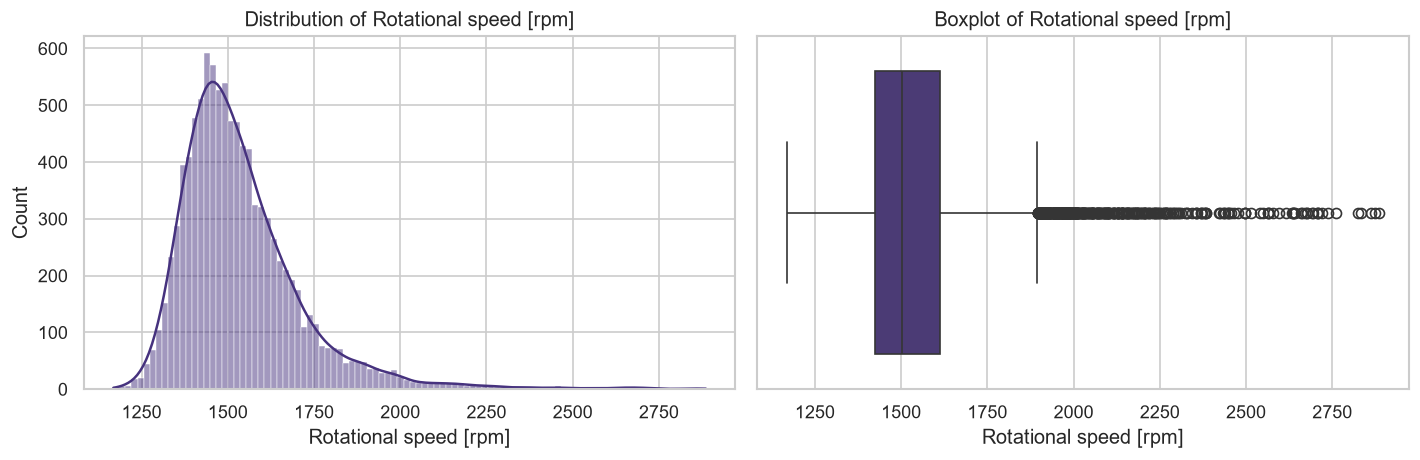

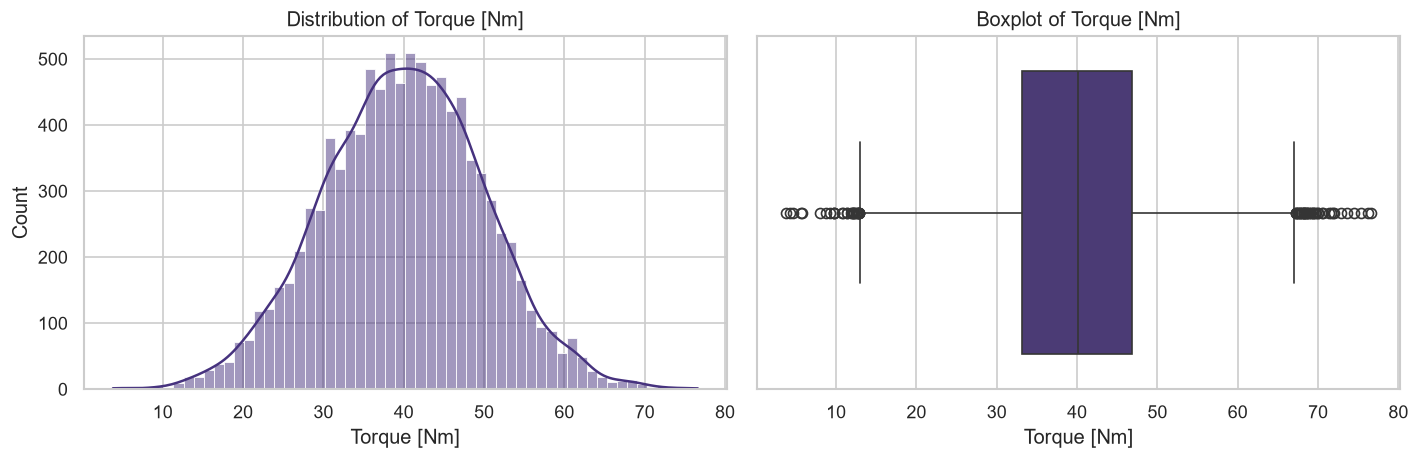

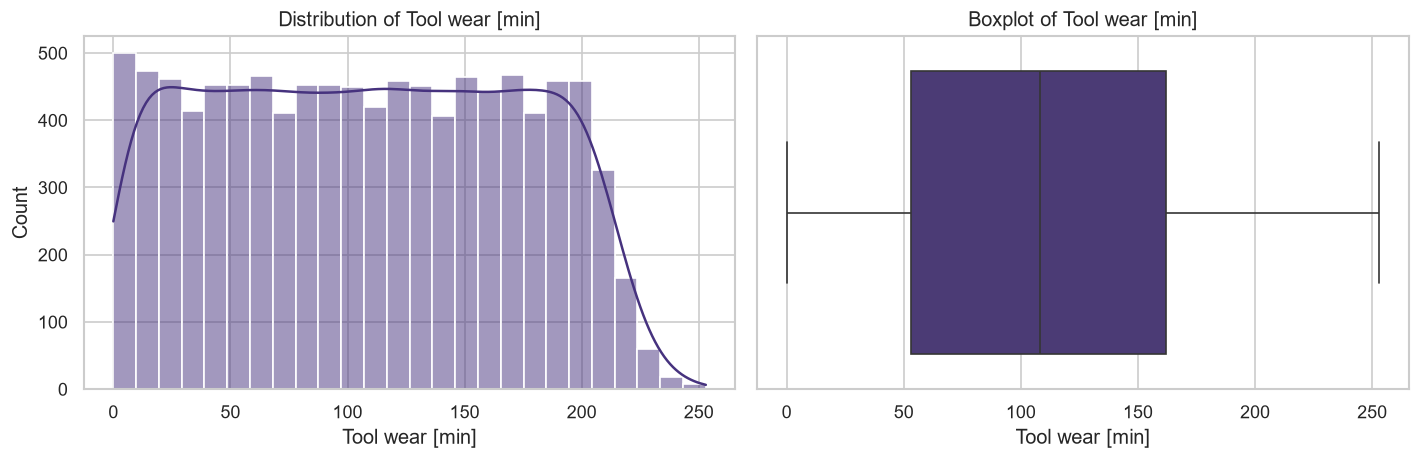

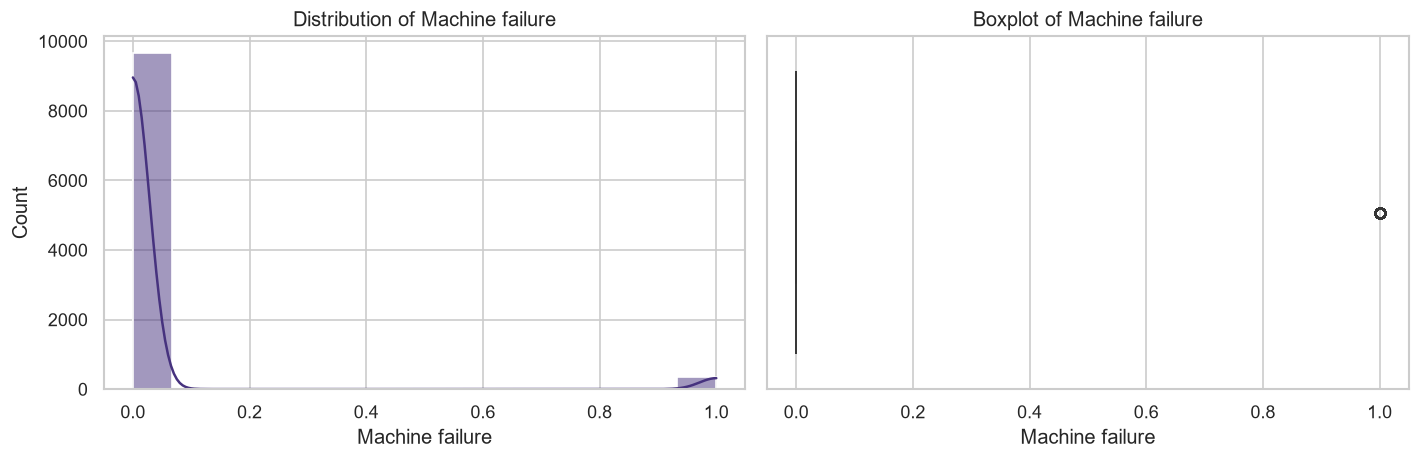

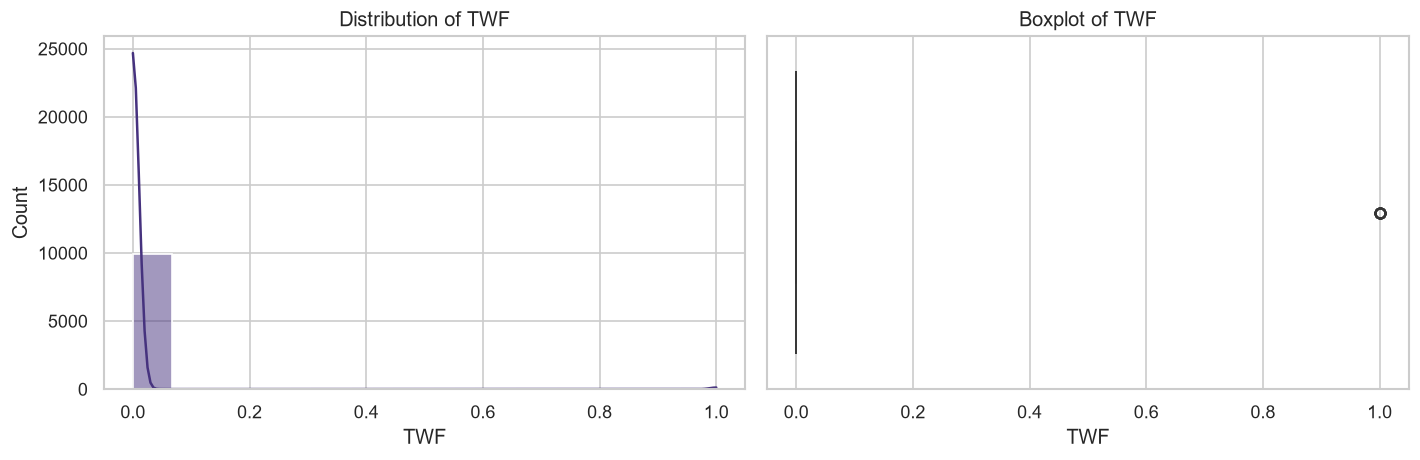

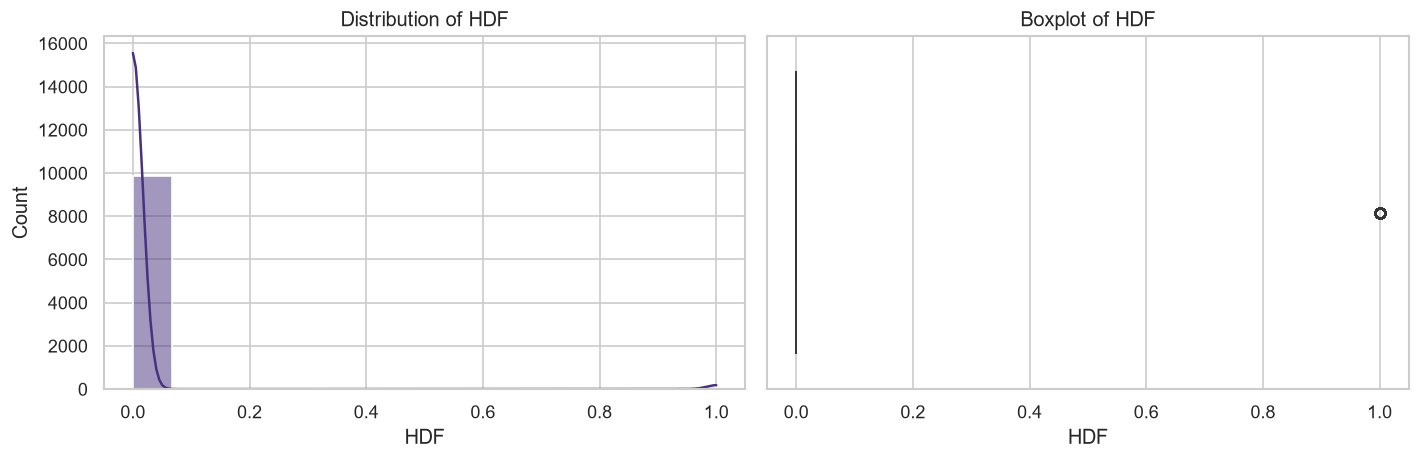

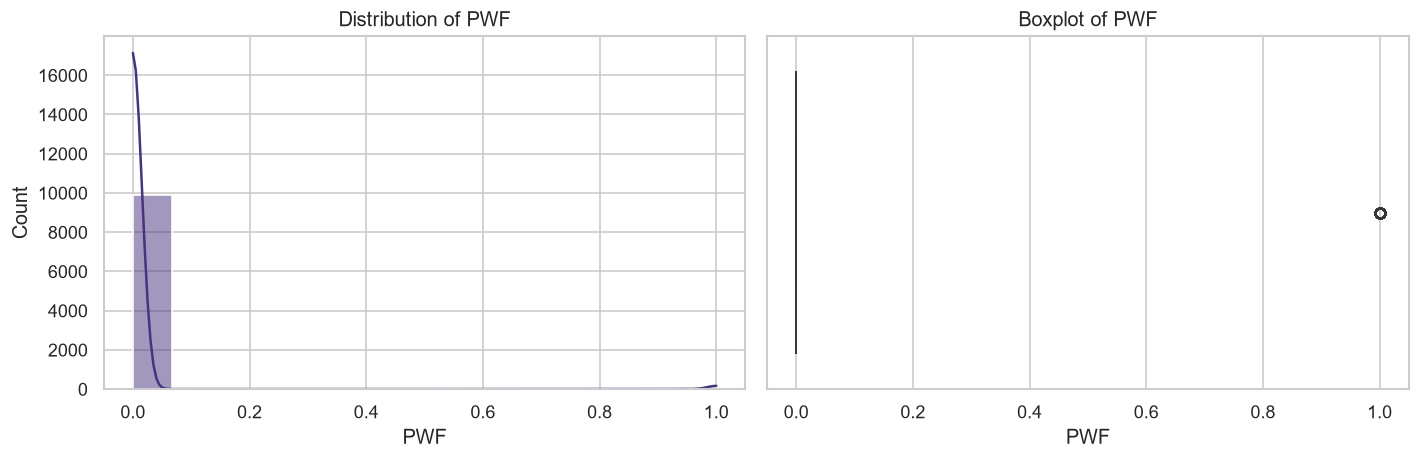

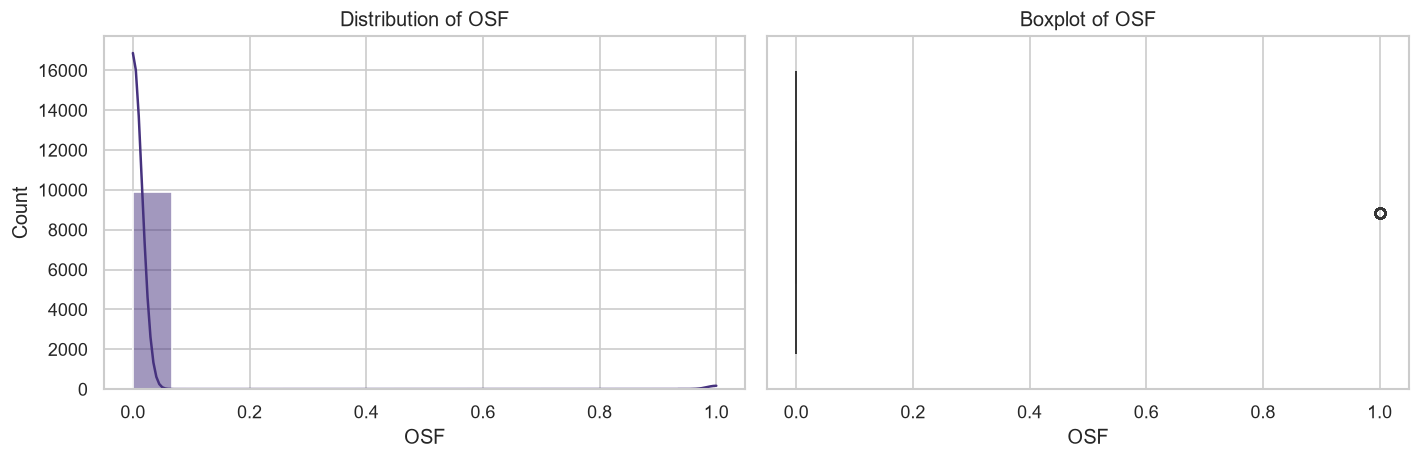

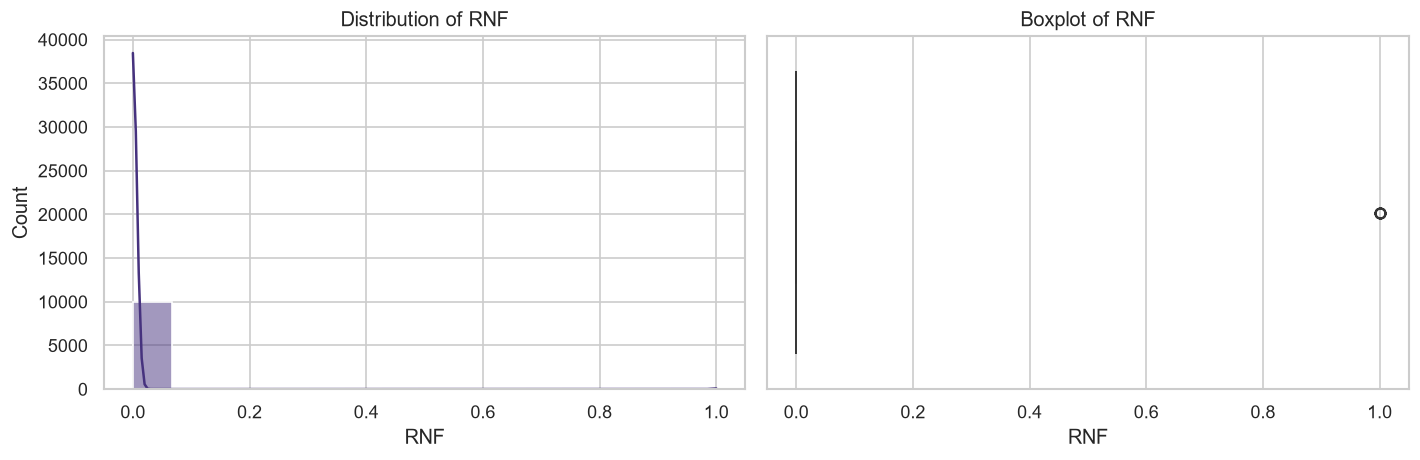

In [13]:
for col in num_cols:

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(df[col], kde=True, ax=ax[0])

    sns.boxplot(x=df[col], ax=ax[1])

    ax[0].set_title(f"Distribution of {col}")
    ax[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

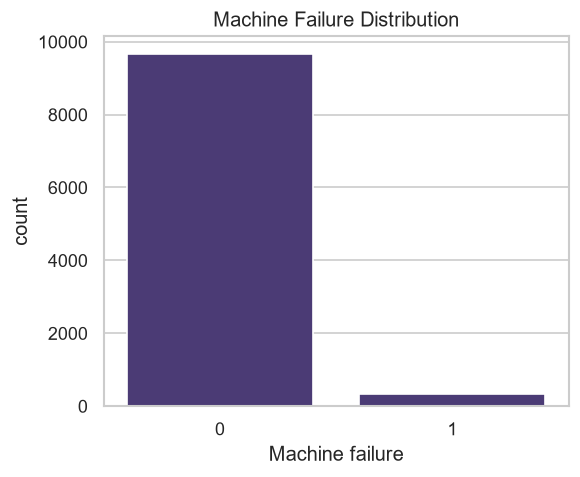

Machine failure
0   96.61
1    3.39
Name: proportion, dtype: float64

In [14]:
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")

plt.show()

df["Machine failure"].value_counts(normalize=True)*100

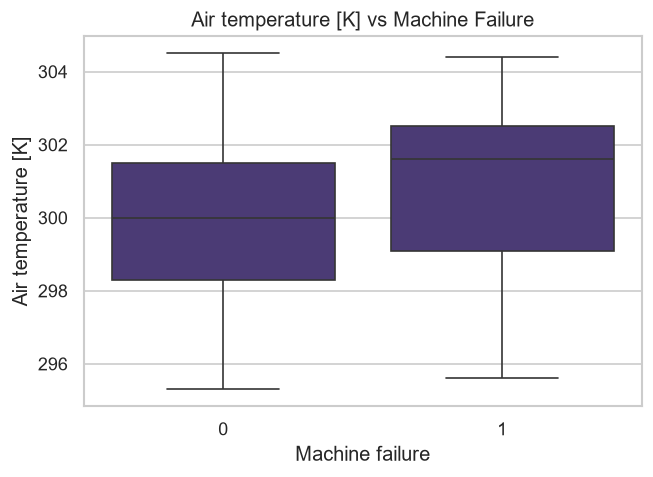

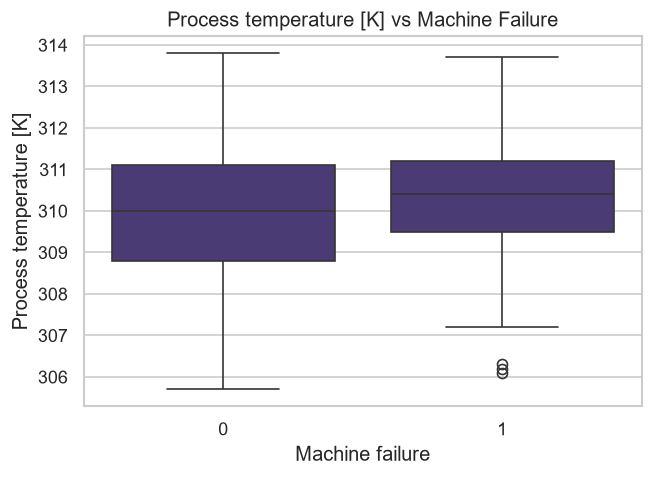

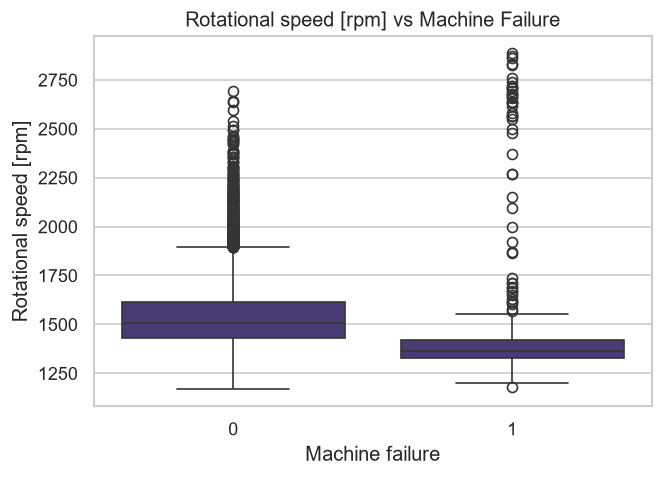

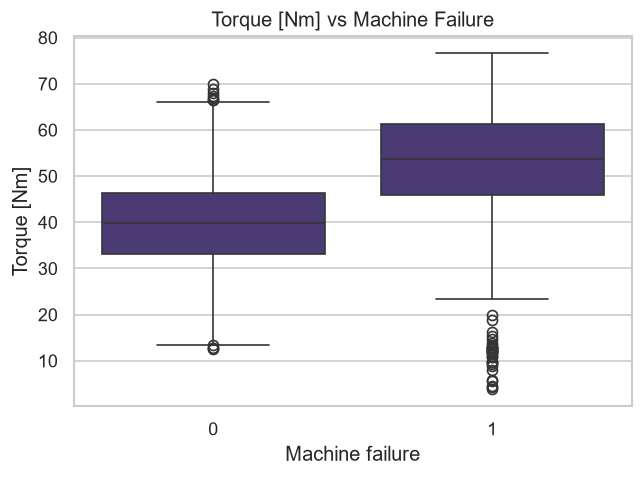

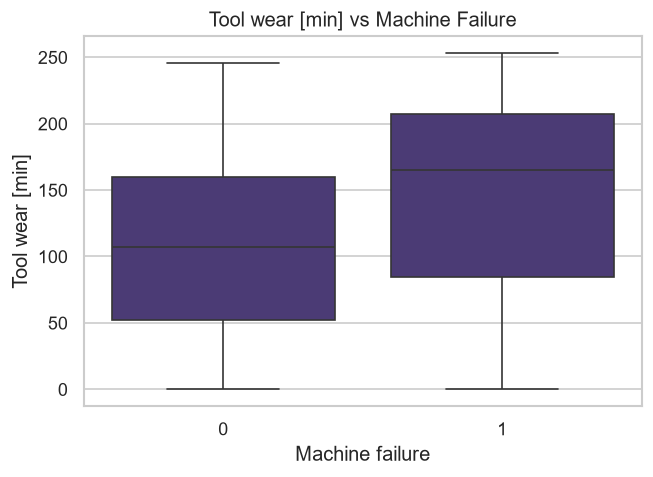

In [15]:
for col in [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=col
    )

    plt.title(f"{col} vs Machine Failure")

    plt.show()

In [16]:
pd.crosstab(df["Type"], df["Machine failure"])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


<Axes: xlabel='Type', ylabel='count'>

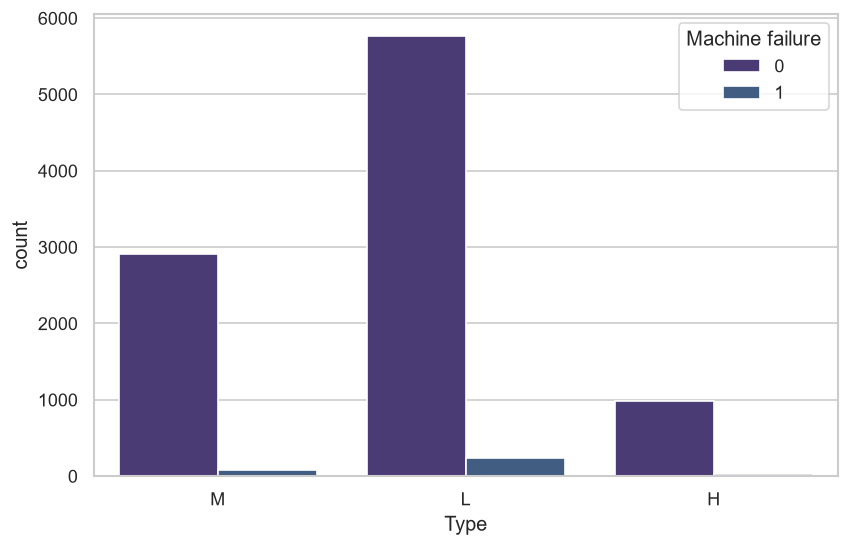

In [17]:
sns.countplot(
    data=df,
    x="Type",
    hue="Machine failure"
)

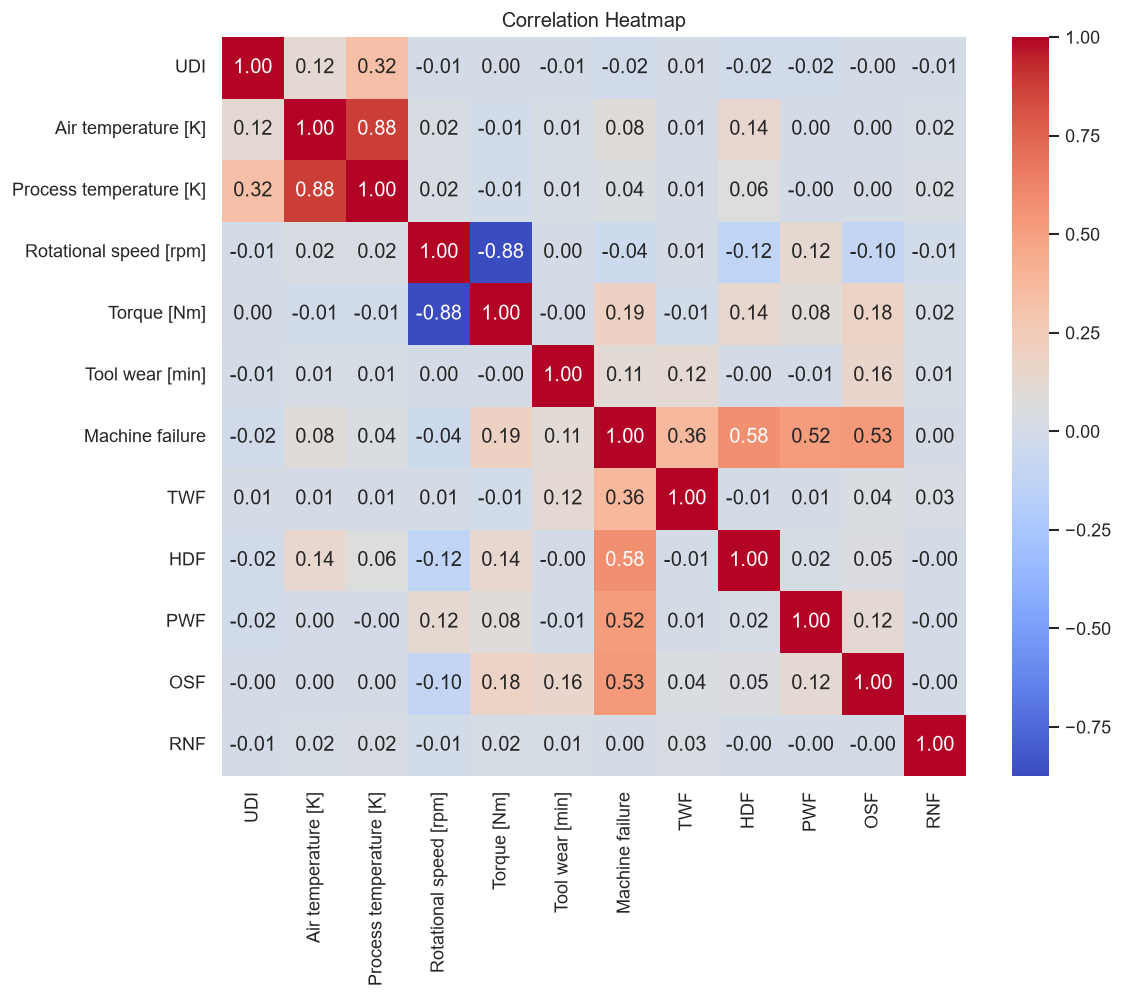

In [18]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

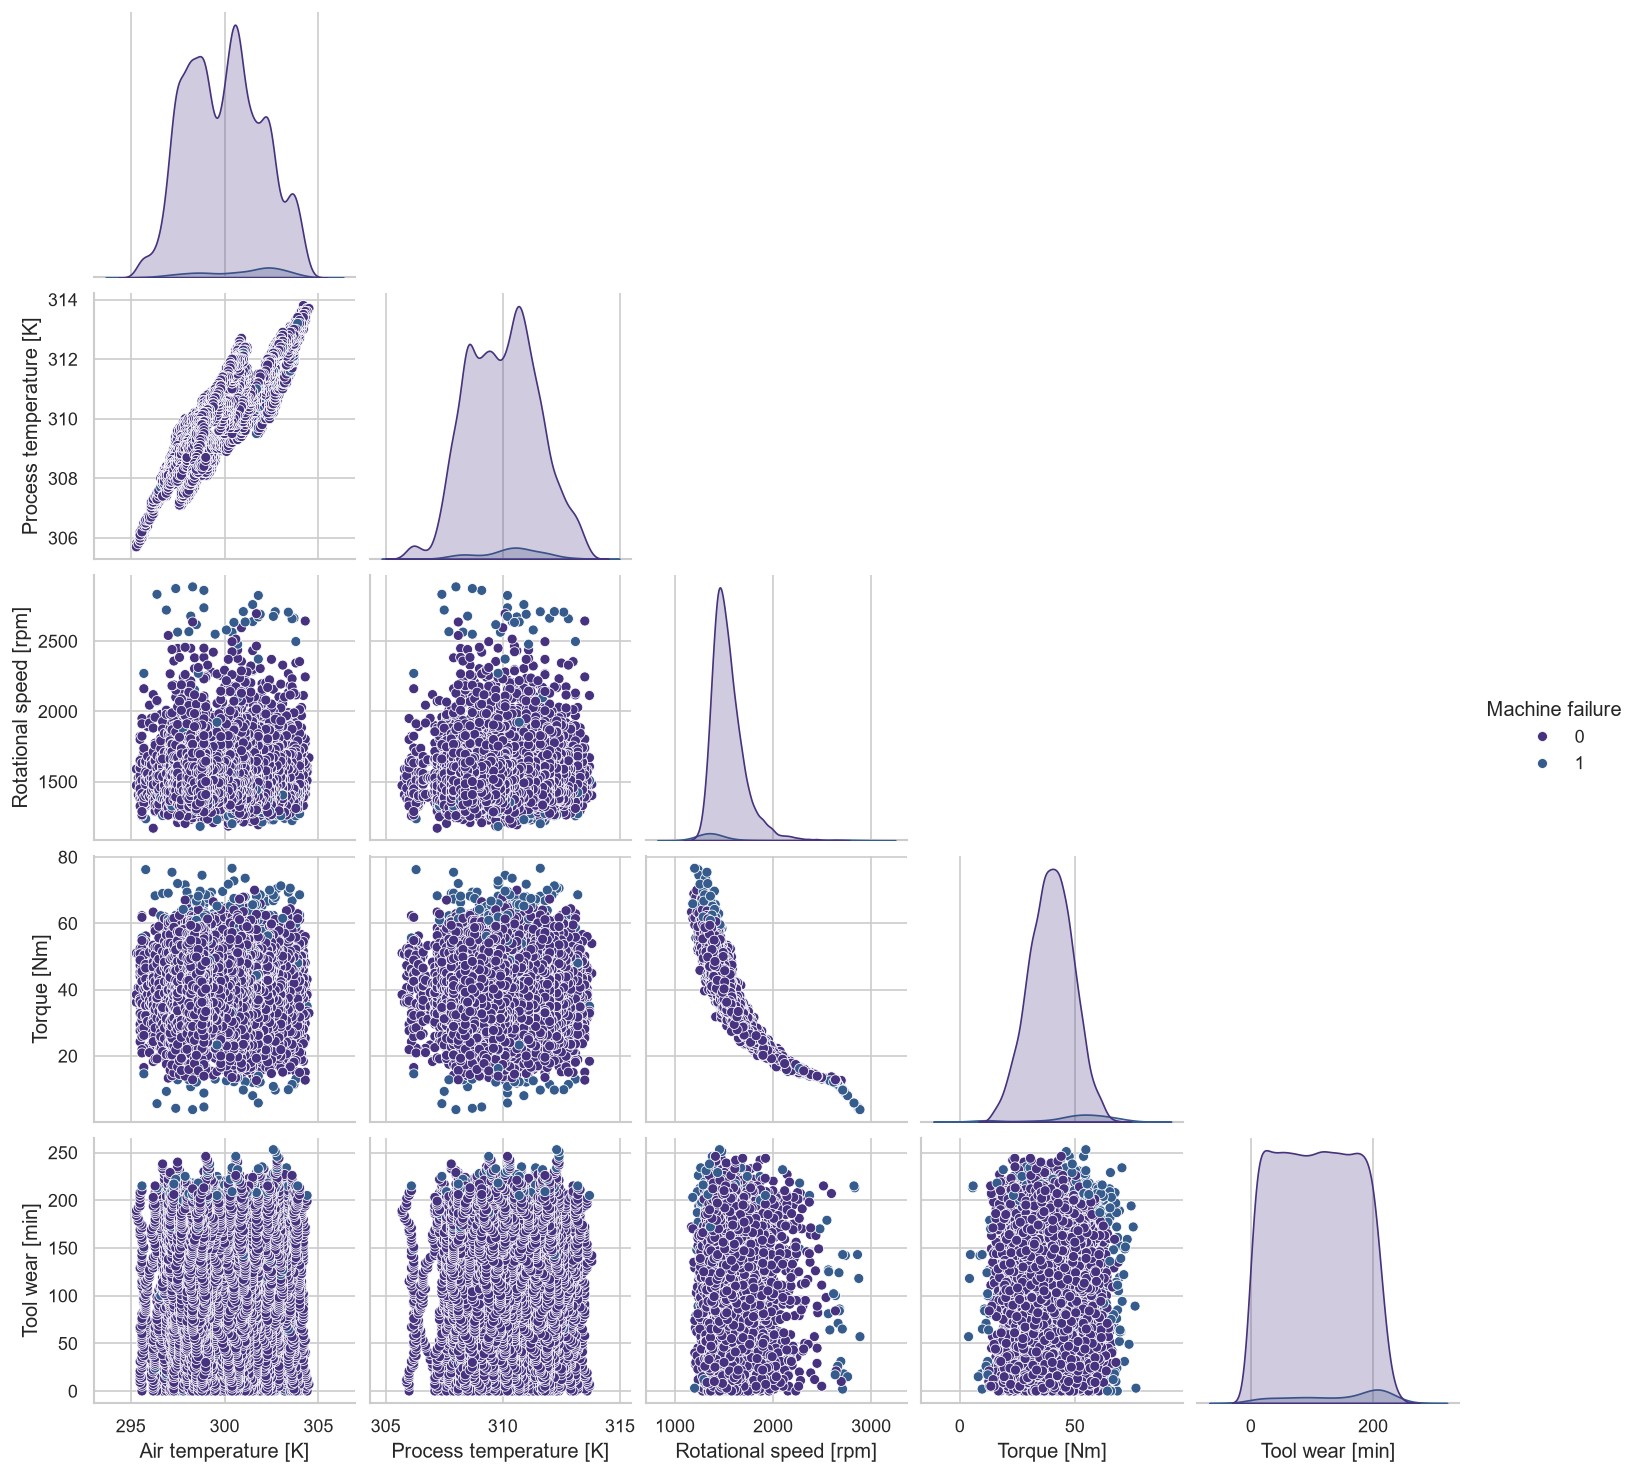

In [19]:
important_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]

sns.pairplot(
    df[important_cols],
    hue="Machine failure",
    corner=True
)

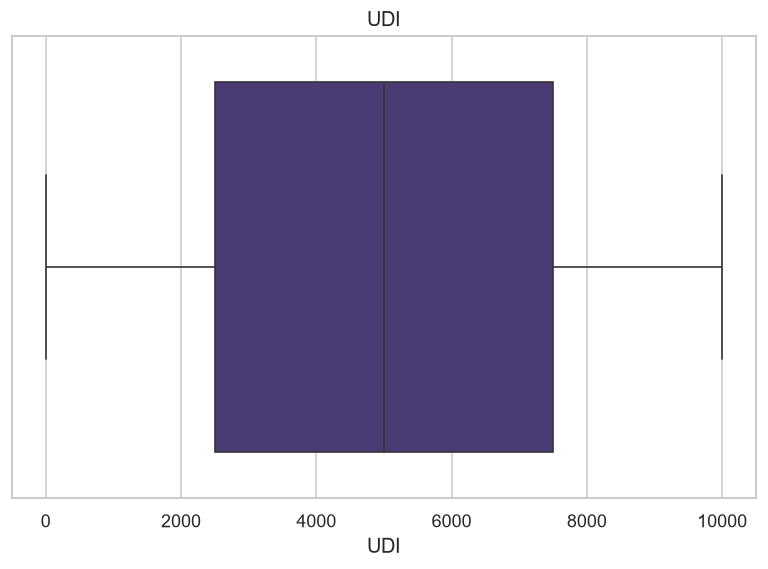

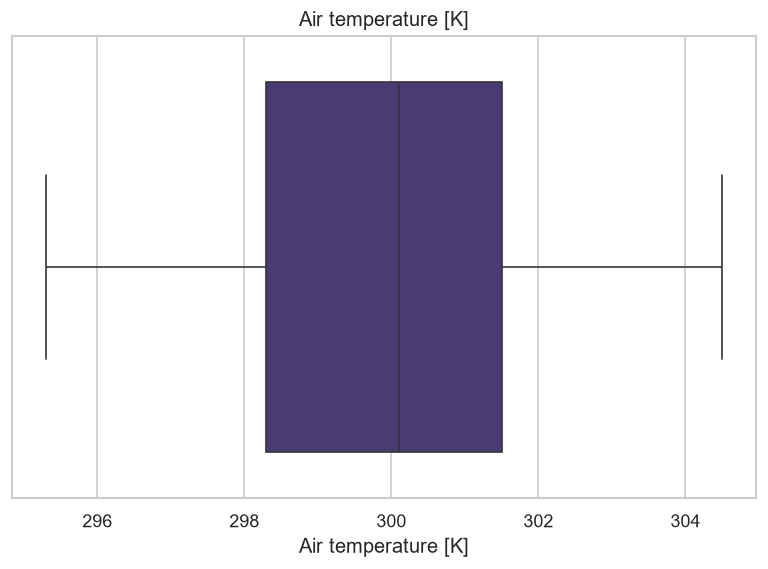

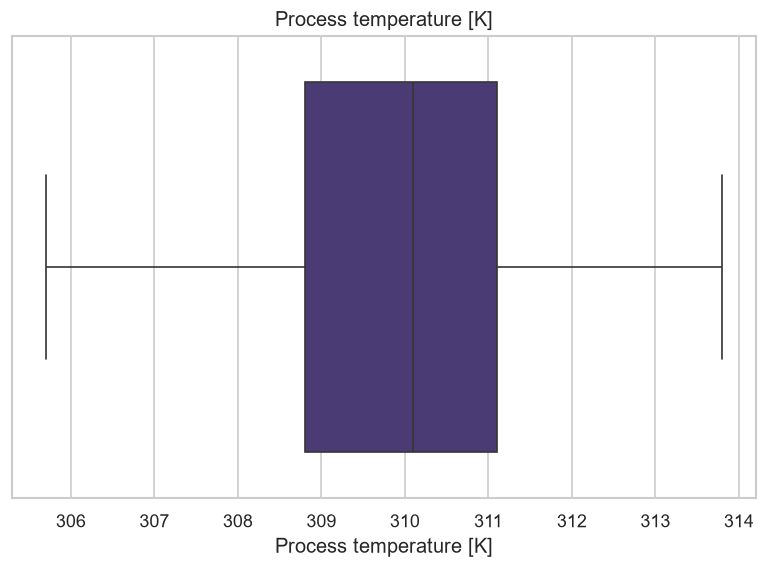

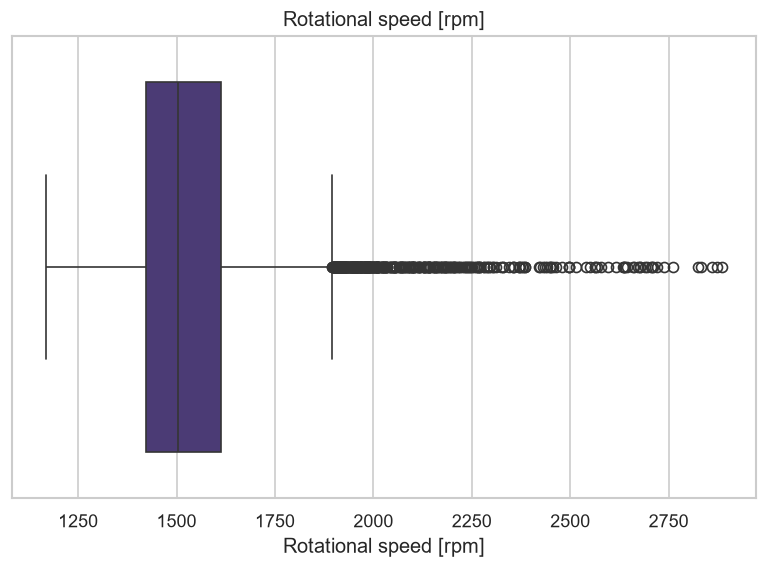

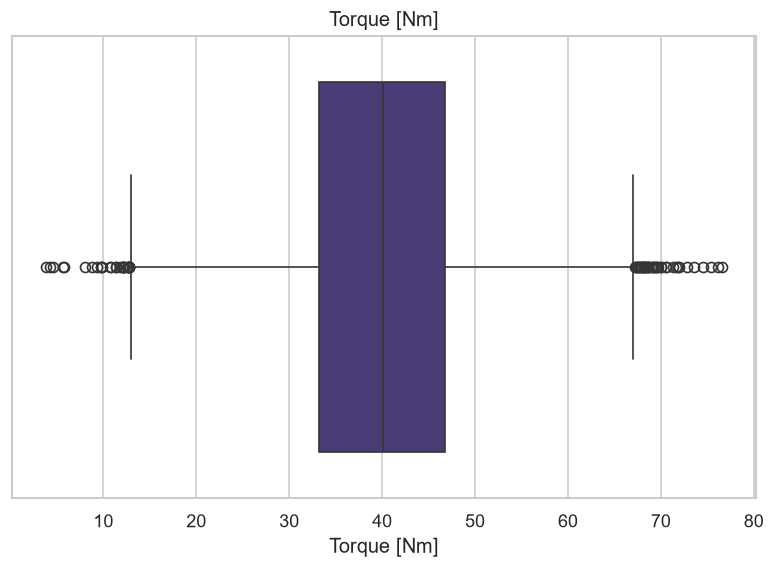

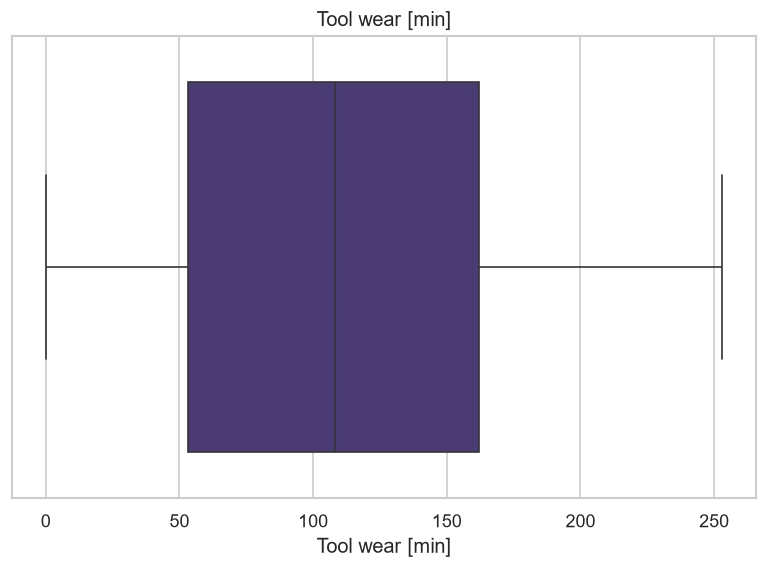

In [20]:
for col in num_cols[:-6]:
    sns.boxplot(data=df, x=col)
    plt.title(col)
    plt.show()

In [21]:
outlier_summary = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier_summary[col] = ((df[col]<lower) | (df[col]>upper)).mean()*100

pd.DataFrame.from_dict(
    outlier_summary,
    orient="index",
    columns=["Outliers"]
)

,Outliers
UDI,0.00
Air temperature [K],0.00
Process temperature [K],0.00
Rotational speed [rpm],4.18
Torque [Nm],0.69
Tool wear [min],0.00
Machine failure,3.39
TWF,0.46
HDF,1.15
PWF,0.95


<Axes: xlabel='Temperature Difference', ylabel='Count'>

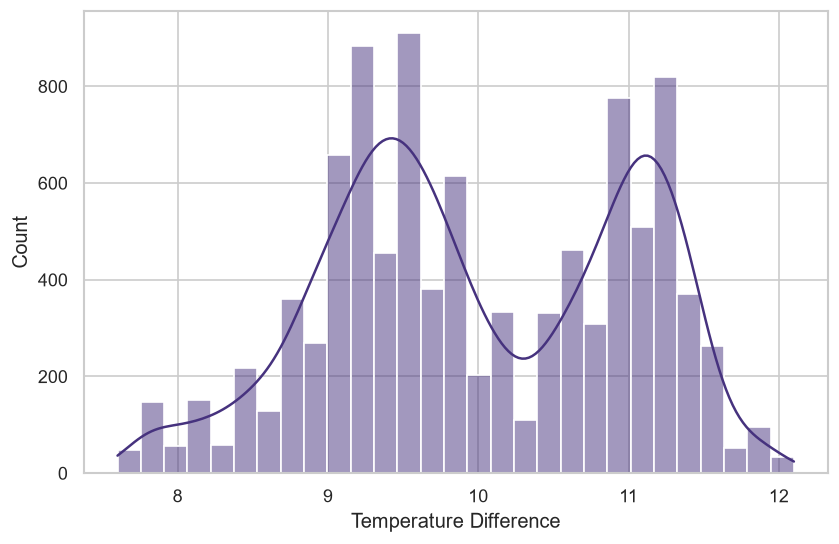

In [22]:
df["Temperature Difference"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)
sns.histplot(df["Temperature Difference"], kde=True)

In [23]:
failure_cols = ["TWF","HDF","PWF","OSF","RNF"]

df[failure_cols].sum().sort_values()

RNF     19
TWF     46
PWF     95
OSF     98
HDF    115
dtype: int64

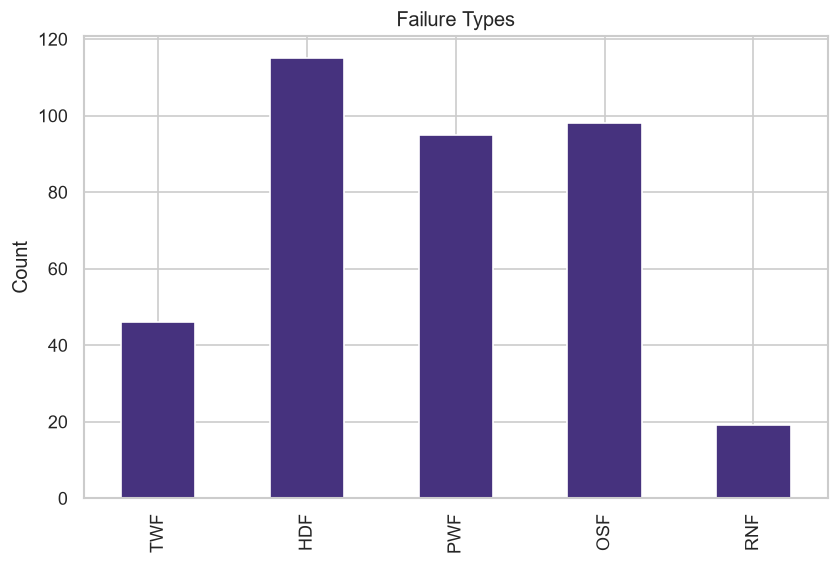

In [24]:
df[failure_cols].sum().plot(
    kind="bar"
)
plt.ylabel("Count")
plt.title("Failure Types")
plt.show()